In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')
df = df[df['Desired_Savings'] > 0].copy()

df['perc_nao_essenciais'] = (df['Eating_Out'] + df['Entertainment']) / df['Income']
df['perc_emprestimo'] = df['Loan_Repayment'] / df['Income']
df['Vulnerable'] = ((df['perc_emprestimo'] > 0.10).astype(int) + 
                    ((df['Disposable_Income'] - df['Desired_Savings']) / df['Income'] < 0.10).astype(int) + 
                    (df['Potential_Savings_Groceries'] / df['Income'] > 0.08).astype(int) >= 2).astype(int)

df['Rent_Ratio'] = df['Rent'] / df['Income']
df['Healthcare_Ratio'] = df['Healthcare'] / df['Income']
df['Education_Ratio'] = df['Education'] / df['Income']
df['Groceries_Ratio'] = df['Groceries'] / df['Income']
df['Transport_Ratio'] = df['Transport'] / df['Income']
df['Utilities_Ratio'] = df['Utilities'] / df['Income']
df['Insurance_Ratio'] = df['Insurance'] / df['Income']



features_percentuais = [
    'Age', 
    'Dependents', 
    'Rent_Ratio', 
    'Healthcare_Ratio', 
    'Education_Ratio', 
    'Groceries_Ratio',
    'Transport_Ratio',
    'Utilities_Ratio',
    'Insurance_Ratio'
]

X = df[features_percentuais]
y = df['Vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)




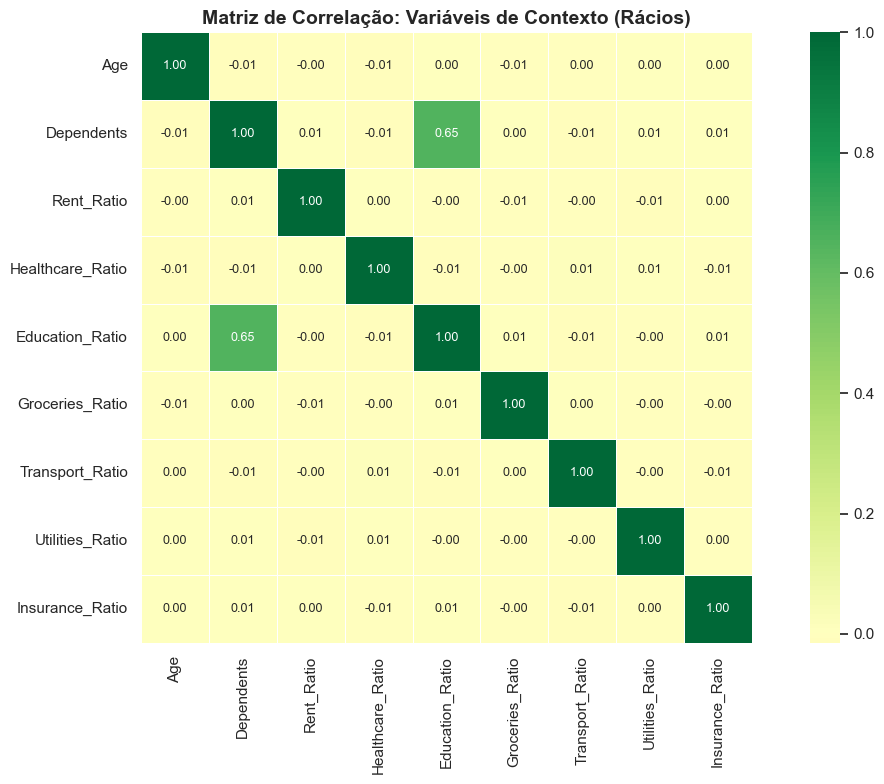


 ALERTA DE MULTICOLINEARIDADE (Correlação > 0.7 ou < -0.7) 
------------------------------------------------------------


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

features_percentuais = [
    'Age',
    'Dependents',
    'Rent_Ratio',
    'Healthcare_Ratio',
    'Education_Ratio',
    'Groceries_Ratio',
    'Transport_Ratio',
    'Utilities_Ratio',
    'Insurance_Ratio'
]



X_corr = df[features_percentuais]
corr_matrix = X_corr.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Matriz de Correlação: Variáveis de Contexto (Rácios)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n ALERTA DE MULTICOLINEARIDADE (Correlação > 0.7 ou < -0.7) ")
print("------------------------------------------------------------")
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > 0.7:
            if list(corr_matrix.columns).index(row) > list(corr_matrix.columns).index(col):
                print(f"  {row} ↔ {col}: {corr_matrix.loc[row, col]:.2f}")

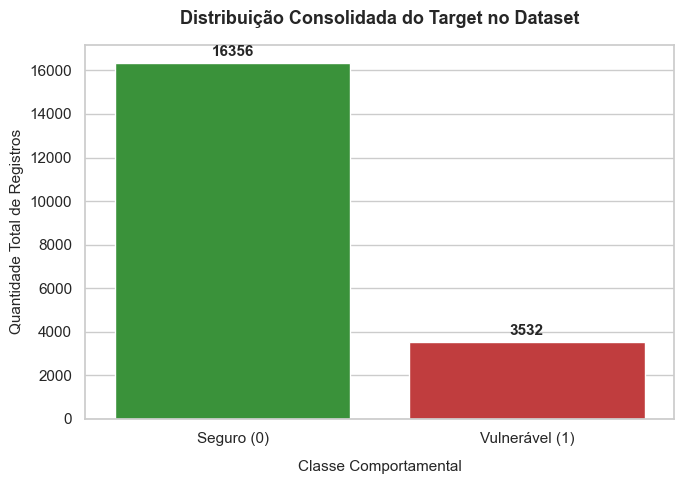

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))


ax = sns.countplot(
    x='Vulnerable', 
    data=df, 
    palette=['#2ca02c', '#d62728'], 
    hue='Vulnerable',
    legend=False
)


for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'{int(altura)}', 
            (p.get_x() + p.get_width() / 2., altura), 
            ha='center', 
            va='center', 
            xytext=(0, 8), 
            textcoords='offset points',
            fontweight='bold',
            fontsize=11
        )


plt.title('Distribuição Consolidada do Target no Dataset', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Classe Comportamental', fontsize=11, labelpad=10)
plt.ylabel('Quantidade Total de Registros', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Seguro (0)', 'Vulnerável (1)'], fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
ratio = n_neg / n_pos

modelos = {
    'Regressão Logística': LogisticRegression(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, n_estimators=100),
    'Gradient Boosting-0.6': GradientBoostingClassifier(random_state=42, subsample=0.6),
    'Gradient Boosting-0.7': GradientBoostingClassifier(random_state=42, subsample=0.7),
    'Gradient Boosting-0.8': GradientBoostingClassifier(random_state=42, subsample=0.8),
    'Gradient Boosting-0.9': GradientBoostingClassifier(random_state=42, subsample=0.9),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=ratio * 0.8, min_child_weight=5, max_depth=5),
    'SVM': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, class_weight={0: 1, 1: ratio * 0.8})),
    'CatBoost': CatBoostClassifier(random_state=42, class_weights=[1, ratio * 0.8], verbose=0)
}

print(f"🔄 Treinando {len(modelos)} algoritmos de alta performance...\n")

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f"{'='*60}")
    print(f" ALGORITMO: {nome}")
    print(f" AUC-ROC: {auc:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Seguro', 'Vulnerável']))
    print("\n")

🔄 Treinando 9 algoritmos de alta performance...

 ALGORITMO: Regressão Logística
 AUC-ROC: 0.6636
              precision    recall  f1-score   support

      Seguro       0.85      0.80      0.82      3272
  Vulnerável       0.27      0.35      0.31       706

    accuracy                           0.72      3978
   macro avg       0.56      0.58      0.57      3978
weighted avg       0.75      0.72      0.73      3978



 ALGORITMO: Random Forest
 AUC-ROC: 0.6259
              precision    recall  f1-score   support

      Seguro       0.82      1.00      0.90      3272
  Vulnerável       0.67      0.00      0.01       706

    accuracy                           0.82      3978
   macro avg       0.74      0.50      0.45      3978
weighted avg       0.80      0.82      0.74      3978



 ALGORITMO: Gradient Boosting-0.6
 AUC-ROC: 0.6472
              precision    recall  f1-score   support

      Seguro       0.82      1.00      0.90      3272
  Vulnerável       0.40      0.00      0.

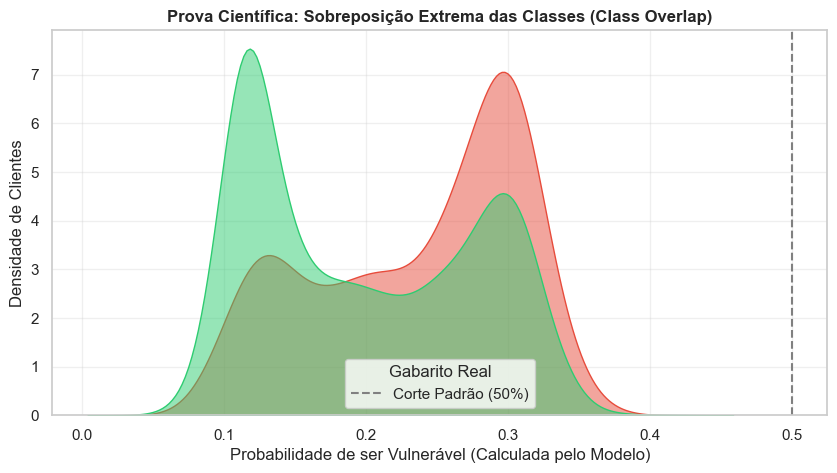

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pegamos o SVM (que é o que melhor tenta separar por curvas/distâncias)
modelo_svm = modelos_selecionados['SVM Otimizado'] # ou treine o modelo SVM isolado se limpou o kernel
y_probabilidades = modelo_svm.predict_proba(X_test_scaled)[:, 1]

# 2. Criamos o DataFrame de visualização
df_plot = pd.DataFrame({'Probabilidade': y_probabilidades, 'Realidade': y_test})
df_plot['Classe'] = df_plot['Realidade'].map({0: 'Seguro (0)', 1: 'Vulnerável (1)'})

# 3. Plotamos o gráfico de densidade cruzada
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_plot, x='Probabilidade', hue='Classe', fill=True, common_norm=False, palette=['#2ecc71', '#e74c3c'], alpha=0.5)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Corte Padrão (50%)')
plt.title('Prova Científica: Sobreposição Extrema das Classes (Class Overlap)', fontsize=12, fontweight='bold')
plt.xlabel('Probabilidade de ser Vulnerável (Calculada pelo Modelo)')
plt.ylabel('Densidade de Clientes')
plt.legend(title='Gabarito Real')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score

# 1. Definição da Rede Neural dentro do Pipeline de Normalização
modelo_mlp = make_pipeline(
    StandardScaler(), 
    MLPClassifier(
        hidden_layer_sizes=(64, 32), 
        activation='relu', 
        solver='adam', 
        max_iter=500,
        early_stopping=True,  # Evita overfitting na classe majoritária
        random_state=42
    )
)

print("🔄 Treinando a Rede Neural Multi-Layer Perceptron (64x32)...\n")

# 2. Treino
modelo_mlp.fit(X_train, y_train)

# 3. Predição de Probabilidades (Crucial para dados desbalanceados)
y_prob = modelo_mlp.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

# 4. Ajuste do Threshold de Decisão para forçar a detecção de Vulneráveis
# Se a probabilidade for maior ou igual a 25%, classificamos como Vulnerável
threshold_customizado = 0.20
y_pred_custom = (y_prob >= threshold_customizado).astype(int)

# 5. Exibição dos Resultados Contornando o Desbalanceamento
print(f"{'='*60}")
print(f" ALGORITMO: MLP Neural Net (64x32) | Threshold: {threshold_customizado}")
print(f" AUC-ROC: {auc:.4f}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_custom, target_names=['Seguro', 'Vulnerável']))

🔄 Treinando a Rede Neural Multi-Layer Perceptron (64x32)...

 ALGORITMO: MLP Neural Net (64x32) | Threshold: 0.2
 AUC-ROC: 0.6415
              precision    recall  f1-score   support

      Seguro       0.87      0.49      0.62      3158
  Vulnerável       0.27      0.72      0.39       842

    accuracy                           0.53      4000
   macro avg       0.57      0.60      0.51      4000
weighted avg       0.74      0.53      0.57      4000



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

# ============================================================
# 🖥️ 1. PREPARAÇÃO E ESCALONAMENTO DOS DADOS (VETOR X E Y)
# ============================================================
# Calculamos a proporção exata para o balanceamento dos pesos internos
n_neg = (df['Vulnerable'] == 0).sum()
n_pos = (df['Vulnerable'] == 1).sum()
ratio = n_neg / n_pos

# Separamos os recursos usando as suas variáveis percentuais
X = df[features_percentuais]
y = df['Vulnerable']

# Divisão em Treino (80%) e Teste (20%) com estratificação para manter as proporções
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicamos o RobustScaler na base para proteger o sinal contra outliers extremos
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


# ============================================================
# ⚙️ 2. NOVO COMITÊ OTIMIZADO (XGBOOST + SVM + REGRESSÃO LOGÍSTICA)
# ============================================================
# Eliminamos o CatBoost e os modelos enviesados para evitar bugs de clonagem
modelos_base = [
    ('XGBoost', XGBClassifier(
        random_state=42, 
        scale_pos_weight=ratio * 0.8, 
        min_child_weight=5, 
        max_depth=5, 
        eval_metric='logloss'
    )),
    
    ('SVM', make_pipeline(
        StandardScaler(), 
        SVC(
            probability=True,  # Habilita explicitamente o cálculo de probabilidades para o Soft Voting
            random_state=42, 
            class_weight={0: 1, 1: ratio * 0.8}
        )
    )),
    
    ('Regressão Logística', LogisticRegression(
        random_state=42, 
        class_weight={0: 1, 1: ratio * 0.8}, 
        max_iter=1000
    ))
]

# Instanciamos o Combinador por Votação Suave (Soft Voting)
# Como não temos mais o CatBoost, o scikit-learn clona e gerencia o comitê perfeitamente
modelo_comite = VotingClassifier(estimators=modelos_base, voting='soft')

print("🚀 Treinando o Comitê de Alta Performance (XGBoost + SVM + Regressão Logística)...\n")
modelo_comite.fit(X_train_scaled, y_train)


# ============================================================
# 🎛️ SIMULADOR DINÂMICO DE RÉGUA COMERCIAL (GRID THRESHOLD)
# ============================================================
# Extraímos as probabilidades contínuas da classe Seguro (Coluna 0)
y_probabilidades_comite = modelo_comite.predict_proba(X_test_scaled)
probabilidade_seguro_media = y_probabilidades_comite[:, 0]

# Lista de réguas de exigência que queremos simular
reguas_para_testar = [0.50,0.53, 0.55,0.58,0.60,0.63,0.65,0.68,0.70,0.73,0.75]

for regua in reguas_para_testar:
    # Aplica o fatiamento baseado na régua atual da iteração
    y_pred_simulado = np.where(probabilidade_seguro_media >= regua, 0, 1)
    
    print("\n" + "="*65)
    print(f"🎯 COMITÊ COMBINADO - SE SEGURO FOR >= {int(regua*100)}% -> APROVA")
    print("="*65)
    print(classification_report(y_test, y_pred_simulado, target_names=['Seguro', 'Vulnerável']))

🚀 Treinando o Comitê de Alta Performance (XGBoost + SVM + Regressão Logística)...


🎯 COMITÊ COMBINADO - SE SEGURO FOR >= 50% -> APROVA
              precision    recall  f1-score   support

      Seguro       0.81      0.90      0.86      3158
  Vulnerável       0.38      0.23      0.29       842

    accuracy                           0.76      4000
   macro avg       0.60      0.56      0.57      4000
weighted avg       0.72      0.76      0.74      4000


🎯 COMITÊ COMBINADO - SE SEGURO FOR >= 53% -> APROVA
              precision    recall  f1-score   support

      Seguro       0.82      0.85      0.84      3158
  Vulnerável       0.35      0.30      0.33       842

    accuracy                           0.74      4000
   macro avg       0.59      0.58      0.58      4000
weighted avg       0.72      0.74      0.73      4000


🎯 COMITÊ COMBINADO - SE SEGURO FOR >= 55% -> APROVA
              precision    recall  f1-score   support

      Seguro       0.82      0.82      0.82      

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

# ============================================================
# 🖥️ 1. PREPARAÇÃO E ESCALONAMENTO DOS DADOS (VETOR X E Y)
# ============================================================
# Calculamos a proporção exata para o balanceamento dos pesos internos
n_neg = (df['Vulnerable'] == 0).sum()
n_pos = (df['Vulnerable'] == 1).sum()
ratio = n_neg / n_pos

# Separamos os recursos usando as suas variáveis percentuais
X = df[features_percentuais]
y = df['Vulnerable']

# Divisão em Treino (80%) e Teste (20%) com estratificação para manter as proporções
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicamos o RobustScaler na base para proteger o sinal contra outliers extremos
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# ============================================================
# ⚙️ 2. CONFIGURAÇÃO DO COMITÊ EM VOTAÇÃO RÍGIDA (HARD VOTING)
# ============================================================
# Instanciamos o comitê mantendo as penalizações ajustadas (ratio * 0.8)
modelos_base = [
    ('XGBoost', XGBClassifier(
        random_state=42, 
        scale_pos_weight=ratio * 0.8, 
        min_child_weight=5, 
        max_depth=5, 
        eval_metric='logloss'
    )),
    
    ('SVM', make_pipeline(
        StandardScaler(), 
        SVC(
            probability=True,  # Mantido por compatibilidade de arquitetura
            random_state=42, 
            class_weight={0: 1, 1: ratio * 0.8}
        )
    )),
    
    ('Regressão Logística', LogisticRegression(
        random_state=42, 
        class_weight={0: 1, 1: ratio * 0.8}, 
        max_iter=1000
    ))
]

# Modificado para 'hard': Decisão baseada na contagem bruta de votos majoritários (2 contra 1)
modelo_comite_hard = VotingClassifier(estimators=modelos_base, voting='hard')

print("🚀 Treinando o Comitê de Alta Performance em Modo Votação Rígida (Hard Voting)...\n")
modelo_comite_hard.fit(X_train_scaled, y_train)

# Previsão direta das classes utilizando a contagem de votos majoritários
y_pred_hard = modelo_comite_hard.predict(X_test_scaled)

# ============================================================
# 📊 3. IMPRESSÃO DO RELATÓRIO OPERACIONAL
# ============================================================
print("="*65)
print("📊 RELATÓRIO DO ENSEMBLE - VOTAÇÃO RÍGIDA (HARD VOTING)")
print("="*65)
print(classification_report(y_test, y_pred_hard, target_names=['Seguro', 'Vulnerável']))

🚀 Treinando o Comitê de Alta Performance em Modo Votação Rígida (Hard Voting)...

📊 RELATÓRIO DO ENSEMBLE - VOTAÇÃO RÍGIDA (HARD VOTING)
              precision    recall  f1-score   support

      Seguro       0.84      0.75      0.79      3158
  Vulnerável       0.33      0.46      0.38       842

    accuracy                           0.69      4000
   macro avg       0.58      0.60      0.59      4000
weighted avg       0.73      0.69      0.70      4000



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
import itertools

# ============================================================
# 🖥️ 1. PREPARAÇÃO E ESCALONAMENTO DOS DADOS (VETOR X E Y)
# ============================================================
# Proporção exata para o balanceamento dos pesos internos
n_neg = (df['Vulnerable'] == 0).sum()
n_pos = (df['Vulnerable'] == 1).sum()
ratio = n_neg / n_pos

X = df[features_percentuais]
y = df['Vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# ============================================================
# ⚙️ 2. MODELOS BASE (MANTENDO AS DIRETRIZES DE TREINO)
# ============================================================
modelos_base = [
    ('XGBoost', XGBClassifier(
        random_state=42, scale_pos_weight=ratio * 0.8, min_child_weight=5, max_depth=5, eval_metric='logloss'
    )),
    ('SVM', make_pipeline(
        StandardScaler(), SVC(probability=True, random_state=42, class_weight={0: 1, 1: ratio * 0.8})
    )),
    ('Regressão Logística', LogisticRegression(
        random_state=42, class_weight={0: 1, 1: ratio * 0.8}, max_iter=1000
    ))
]

# ============================================================
# 🎛️ 3. LOOP EXPERIMENTAL DE TODAS AS COMBINAÇÕES DE PESOS (1 ou 2)
# ============================================================
print("🚀 Iniciando busca em grade para Weighted Hard Voting (Pesos: 1 ou 2)...\n")

# Gera o produto cartesiano de todas as possibilidades: (1,1,1), (1,1,2), ..., (2,2,2)
combinacoes_pesos = list(itertools.product([1, 2], repeat=3))

for pesos in combinacoes_pesos:
    # Desempacota a tupla para facilitar o log no terminal
    w_xgb, w_svm, w_lr = pesos
    
    # Ignoramos redundâncias matemáticas (ex: 2,2,2 entrega a mesma proporção que 1,1,1)
    if w_xgb == 2 and w_svm == 2 and w_lr == 2:
        continue
        
    # Inicializa o comitê rígido aplicando os pesos da iteração
    modelo_comite_hard = VotingClassifier(
        estimators=modelos_base, 
        voting='hard',
        weights=list(pesos)
    )
    
    # Como os modelos base já foram definidos, o fit executa a sequência de treino
    modelo_comite_hard.fit(X_train_scaled, y_train)
    y_pred = modelo_comite_hard.predict(X_test_scaled)
    
    # Impressão formatada dos resultados de cada arranjo de poder
    print("\n" + "="*70)
    print(f"🎯 PESOS HARD VOTING -> XGBoost: {w_xgb} | SVM: {w_svm} | Reg. Logística: {w_lr}")
    print("="*70)
    print(classification_report(y_test, y_pred, target_names=['Seguro', 'Vulnerável']))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
import itertools

# ============================================================
# 🖥️ 1. PREPARAÇÃO E ESCALONAMENTO DOS DADOS (VETOR X E Y)
# ============================================================
# Proporção populacional exata para o balanceamento dos pesos internos
n_neg = (df['Vulnerable'] == 0).sum()
n_pos = (df['Vulnerable'] == 1).sum()
ratio = n_neg / n_pos

X = df[features_percentuais]
y = df['Vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


# ============================================================
# 🎛️ 2. SELEÇÃO DE VARIÁVEIS E PERMUTAÇÕES DO EXPERIMENTO
# ============================================================
# Adicionados os valores refinados de 0.65 e 0.75 solicitados
variacoes_de_fator = [0.6, 0.65, 0.7, 0.75, 0.8, 0.9]

# Gera todas as permutações matemáticas possíveis de pesos de votação (1 ou 2)
permutacoes_de_voto = list(itertools.product([1, 2], repeat=3))

print("⚡ Iniciando a Super Grade Experimental de Hard Voting...")
print(f"📊 Fatores de Treino: {len(variacoes_de_fator)} | Combinações de Voto: {len(permutacoes_de_voto) - 1}")
print("====================================================================\n")

# ============================================================
# 🔄 3. GRID SEARCH BIDIMENSIONAL INTEGRADO
# ============================================================
for fator in variacoes_de_fator:
    # Ajusta o nível de paranoia de treino para esta iteração do loop
    peso_risco = ratio * fator
    
    # Recriamos os modelos injetando a variação de peso atual
    modelos_base_variados = [
        ('XGBoost', XGBClassifier(random_state=42, scale_pos_weight=peso_risco, min_child_weight=5, max_depth=5, eval_metric='logloss')),
        ('SVM', make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, class_weight={0: 1, 1: peso_risco}))),
        ('Regressão Logística', LogisticRegression(random_state=42, class_weight={0: 1, 1: peso_risco}, max_iter=1000))
    ]
    
    for pesos in permutacoes_de_voto:
        w_xgb, w_svm, w_lr = pesos
        
        # Filtro de otimização: ignora pesos proporcionais redundantes (2,2,2 é igual a 1,1,1)
        if w_xgb == 2 and w_svm == 2 and w_lr == 2:
            continue
            
        # Instancia o comitê rígido aplicando a permutação de pesos atual
        comite_hard_otimizado = VotingClassifier(
            estimators=modelos_base_variados, 
            voting='hard',
            weights=list(pesos)
        )
        
        # Executa o ciclo de treino e teste
        comite_hard_otimizado.fit(X_train_scaled, y_train)
        y_pred_simulado = comite_hard_otimizado.predict(X_test_scaled)
        
        # Impressão limpa e padronizada de cada cenário no terminal
        print("\n" + "="*75)
        print(f"🎯 FATOR TREINO: {fator} | PESOS VOTO -> XGB: {w_xgb} | SVM: {w_svm} | LR: {w_lr}")
        print("="*75)
        print(classification_report(y_test, y_pred_simulado, target_names=['Seguro', 'Vulnerável']))